# Monte Carlo Scenario Stress Testing

This notebook extends the regression-based scenario analysis with Monte Carlo simulation.

The key idea is:

- the regression model gives the expected quarterly change in NPL under each macro scenario;
- Monte Carlo adds random residual shocks around this expected path;
- the result is not one deterministic NPL forecast, but a **distribution of possible NPL outcomes**.

Note that simulations are built around the scenarios used in `04_scenario_design.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path

In [2]:
data_path = Path("../../data_final/regression_dataset.xlsx")
output_dir = Path("../../data_final/monte_carlo_results")
output_dir.mkdir(parents=True, exist_ok=True)

N_SIMULATIONS = 10_000
RANDOM_SEED = 42

rng = np.random.default_rng(RANDOM_SEED)

In [3]:
# load regression dataset

df = pd.read_excel(data_path)

required_columns = [
    "NPL",
    "d_NPL",
    "gdp_growth_lag1",
    "policy_rate_lag1",
    "fx_change_lag1",
    "residuals"
]

df = df[required_columns].dropna().copy()

display(df.tail())

,NPL,d_NPL,gdp_growth_lag1,policy_rate_lag1,fx_change_lag1,residuals
25,37.351358,-0.520370,0.097,21.333333,0.000000,0.439232
26,36.066158,-1.285200,0.052,15.666667,0.009234,0.055902
27,34.570918,-1.495240,0.068,14.833333,0.040533,-0.160943
28,32.336924,-2.233994,0.040,13.333333,0.045791,-0.951809
29,30.288271,-2.048653,0.022,13.000000,0.021954,-0.668048


In [4]:
# final regression coefficients
beta_const = -3.2663
beta_gdp = -8.0813
beta_policy = 0.1449
beta_fx = 8.2056

# historical regression errors to estimate the size of random shocks for Monte Carlo simulation
residuals = df["residuals"].dropna().to_numpy()
residual_std = residuals.std(ddof=1)

print(f"Number of residuals used: {len(residuals)}")
print(f"Residual standard deviation: {residual_std:.4f}")

Number of residuals used: 30
Residual standard deviation: 1.3030


## Define macroeconomic scenarios

In [5]:
scenario_annual = pd.DataFrame({
    "scenario": ["baseline", "adverse", "severe adverse"],
    "gdp_growth_percent": [3.1, -3.1, -5.0],
    "CPI_percent": [8.7, 17.9, 22.0],
    "fx_change_percent": [5.9, 11.2, 18.0],
    "policy_rate": [14.0, 16.0, 20.0]
})

quarters = pd.period_range("2025Q1", "2025Q4", freq="Q")

scenario_rows = []

for _, row in scenario_annual.iterrows():
    for q in quarters:
        scenario_rows.append({
            "quarter": q,
            "scenario": row["scenario"],
            "gdp_growth_percent": row["gdp_growth_percent"],
            "CPI_percent": row["CPI_percent"],
            "fx_change_percent": row["fx_change_percent"],
            "policy_rate": row["policy_rate"]
        })

scenario_quarterly = pd.DataFrame(scenario_rows)

scenario_quarterly["gdp_growth"] = scenario_quarterly["gdp_growth_percent"] / 100
scenario_quarterly["fx_change"] = np.log(
    1 + scenario_quarterly["fx_change_percent"] / 100
) / 4

display(scenario_quarterly)

,quarter,scenario,gdp_growth_percent,CPI_percent,fx_change_percent,policy_rate,gdp_growth,fx_change
0,2025Q1,baseline,3.1,8.7,5.9,14.0,0.031,0.014331
1,2025Q2,baseline,3.1,8.7,5.9,14.0,0.031,0.014331
2,2025Q3,baseline,3.1,8.7,5.9,14.0,0.031,0.014331
3,2025Q4,baseline,3.1,8.7,5.9,14.0,0.031,0.014331
4,2025Q1,adverse,-3.1,17.9,11.2,16.0,-0.031,0.026540
5,2025Q2,adverse,-3.1,17.9,11.2,16.0,-0.031,0.026540
6,2025Q3,adverse,-3.1,17.9,11.2,16.0,-0.031,0.026540
7,2025Q4,adverse,-3.1,17.9,11.2,16.0,-0.031,0.026540
8,2025Q1,severe adverse,-5.0,22.0,18.0,20.0,-0.050,0.041379
9,2025Q2,severe adverse,-5.0,22.0,18.0,20.0,-0.050,0.041379


## Build deterministic scenario path

In [6]:
scenario_quarterly["predicted_d_NPL"] = (
    beta_const
    + beta_gdp * scenario_quarterly["gdp_growth"]
    + beta_policy * scenario_quarterly["policy_rate"]
    + beta_fx * scenario_quarterly["fx_change"]
)

current_npl = df["NPL"].iloc[-1]
last_actual_quarter = "2024Q4"

print("Last actual quarter:", last_actual_quarter)
print(f"Current NPL: {current_npl:.4f}")

deterministic_paths = []

for scenario_name, group in scenario_quarterly.groupby("scenario", sort=False):
    group = group.sort_values("quarter").copy()
    npl = current_npl
    projected_values = []

    for _, row in group.iterrows():
        npl = npl + row["predicted_d_NPL"]
        npl = np.clip(npl, 0, 100)
        projected_values.append(npl)

    group["deterministic_NPL"] = projected_values
    deterministic_paths.append(group)

deterministic_paths = pd.concat(deterministic_paths, ignore_index=True)

display(
    deterministic_paths[
        ["quarter", "scenario", "predicted_d_NPL", "deterministic_NPL"]
    ].round(4)
)

Last actual quarter: 2024Q4
Current NPL: 30.2883


,quarter,scenario,predicted_d_NPL,deterministic_NPL
0,2025Q1,baseline,-1.3706,28.9176
1,2025Q2,baseline,-1.3706,27.5470
2,2025Q3,baseline,-1.3706,26.1764
3,2025Q4,baseline,-1.3706,24.8058
4,2025Q1,adverse,-0.4796,29.8087
5,2025Q2,adverse,-0.4796,29.3291
6,2025Q3,adverse,-0.4796,28.8495
7,2025Q4,adverse,-0.4796,28.3699
8,2025Q1,severe adverse,0.3753,30.6636
9,2025Q2,severe adverse,0.3753,31.0389


## Monte Carlo simulation

For each scenario and each quarter:

1. Take the deterministic predicted `d_NPL`
2. Add a random residual shock
3. Accumulate the simulated `d_NPL` into the NPL level
4. Constrain NPL to the interval [0, 100]

In [7]:
projection_labels = ["Start"] + [str(q) for q in quarters]

all_simulation_paths = {}

for scenario_name, group in scenario_quarterly.groupby("scenario", sort=False):
    group = group.sort_values("quarter").copy()
    expected_d_npl = group["predicted_d_NPL"].to_numpy()

    paths = np.zeros((N_SIMULATIONS, len(expected_d_npl) + 1))
    paths[:, 0] = current_npl

    for i in range(N_SIMULATIONS):
        npl = current_npl

        for t, expected_change in enumerate(expected_d_npl):
            shock = rng.normal(loc=0, scale=residual_std)

            simulated_d_npl = expected_change + shock
            npl = np.clip(npl + simulated_d_npl, 0, 100)
            paths[i, t + 1] = npl

    all_simulation_paths[scenario_name] = pd.DataFrame(
        paths,
        columns=projection_labels
    )

list(all_simulation_paths.keys())

['baseline', 'adverse', 'severe adverse']

## Final NPL distribution by scenario

In [8]:
summary_rows = []

for scenario_name, paths_df in all_simulation_paths.items():
    final_distribution = paths_df[projection_labels[-1]].to_numpy()

    summary_rows.append({
        "scenario": scenario_name,
        "mean": np.mean(final_distribution),
        "median": np.median(final_distribution),
        "std": np.std(final_distribution, ddof=1),
        "p01": np.percentile(final_distribution, 1),
        "p05": np.percentile(final_distribution, 5),
        "p25": np.percentile(final_distribution, 25),
        "p75": np.percentile(final_distribution, 75),
        "p95": np.percentile(final_distribution, 95),
        "p99": np.percentile(final_distribution, 99),
        "min": np.min(final_distribution),
        "max": np.max(final_distribution)
    })

summary_statistics = pd.DataFrame(summary_rows)

display(summary_statistics.round(4))

,scenario,mean,median,std,p01,p05,p25,p75,p95,p99,min,max
0,baseline,24.8288,24.8128,2.6249,18.8937,20.6089,23.0060,26.5974,29.1486,31.1123,15.0703,36.4938
1,adverse,28.3255,28.3301,2.6112,22.1745,24.0826,26.5744,30.0863,32.6178,34.3850,18.6686,38.0665
2,severe adverse,31.7519,31.7678,2.6123,25.7641,27.4730,29.9641,33.4867,36.0684,37.8179,22.2710,42.8014


In [9]:
risk_rows = []

for scenario_name, paths_df in all_simulation_paths.items():
    final_distribution = paths_df[projection_labels[-1]].to_numpy()

    risk_rows.append({
        "scenario": scenario_name,
        "P(final NPL > current NPL)": np.mean(final_distribution > current_npl),
        "P(final NPL > 30%)": np.mean(final_distribution > 30),
        "P(final NPL > 35%)": np.mean(final_distribution > 35),
        "P(final NPL > 40%)": np.mean(final_distribution > 40)
    })

risk_indicators = pd.DataFrame(risk_rows)

display(risk_indicators.round(4))

,scenario,P(final NPL > current NPL),P(final NPL > 30%),P(final NPL > 35%),P(final NPL > 40%)
0,baseline,0.0221,0.0267,0.0001,0.0000
1,adverse,0.2268,0.2589,0.0057,0.0000
2,severe adverse,0.7102,0.7458,0.1063,0.0011


## Percentile paths

In [10]:
percentile_tables = []

for scenario_name, paths_df in all_simulation_paths.items():
    paths = paths_df.to_numpy()

    temp = pd.DataFrame({
        "scenario": scenario_name,
        "quarter": projection_labels,
        "p05": np.percentile(paths, 5, axis=0),
        "p25": np.percentile(paths, 25, axis=0),
        "median": np.percentile(paths, 50, axis=0),
        "p75": np.percentile(paths, 75, axis=0),
        "p95": np.percentile(paths, 95, axis=0)
    })

    percentile_tables.append(temp)

percentile_paths = pd.concat(percentile_tables, ignore_index=True)

display(percentile_paths.round(4))

,scenario,quarter,p05,p25,median,p75,p95
0,baseline,Start,30.2883,30.2883,30.2883,30.2883,30.2883
1,baseline,2025Q1,26.8003,28.0474,28.9041,29.7719,31.0841
2,baseline,2025Q2,24.5542,26.3182,27.5554,28.8291,30.6684
3,baseline,2025Q3,22.5276,24.6400,26.1880,27.7081,30.0227
4,baseline,2025Q4,20.6089,23.0060,24.8128,26.5974,29.1486
5,adverse,Start,30.2883,30.2883,30.2883,30.2883,30.2883
6,adverse,2025Q1,27.6659,28.9336,29.7962,30.6762,31.9761
7,adverse,2025Q2,26.2251,28.0891,29.3329,30.5807,32.3292
8,adverse,2025Q3,25.1148,27.3066,28.8217,30.3636,32.4954
9,adverse,2025Q4,24.0826,26.5744,28.3301,30.0863,32.6178


## Visualise final distributions

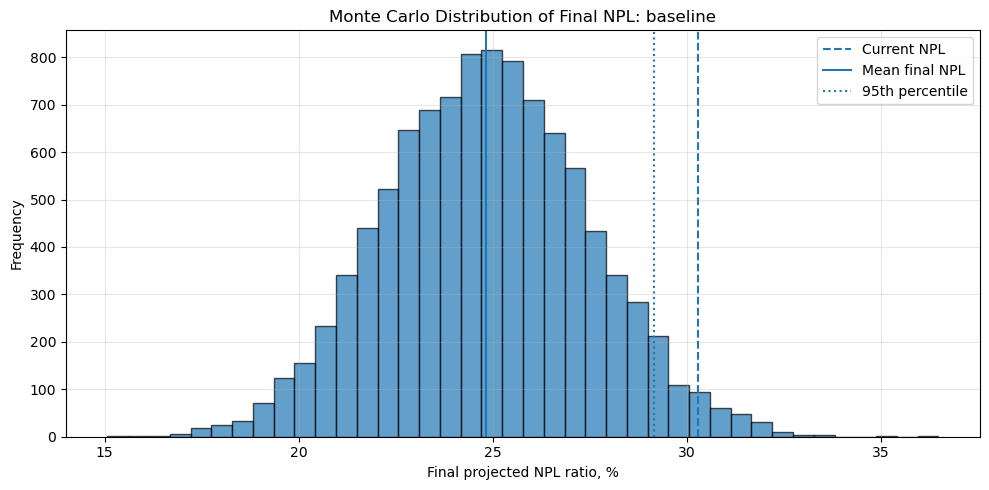

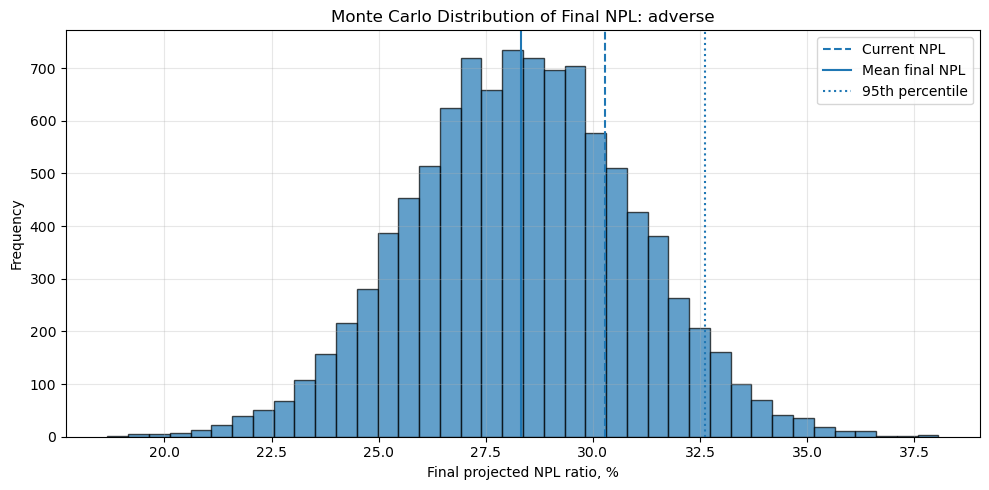

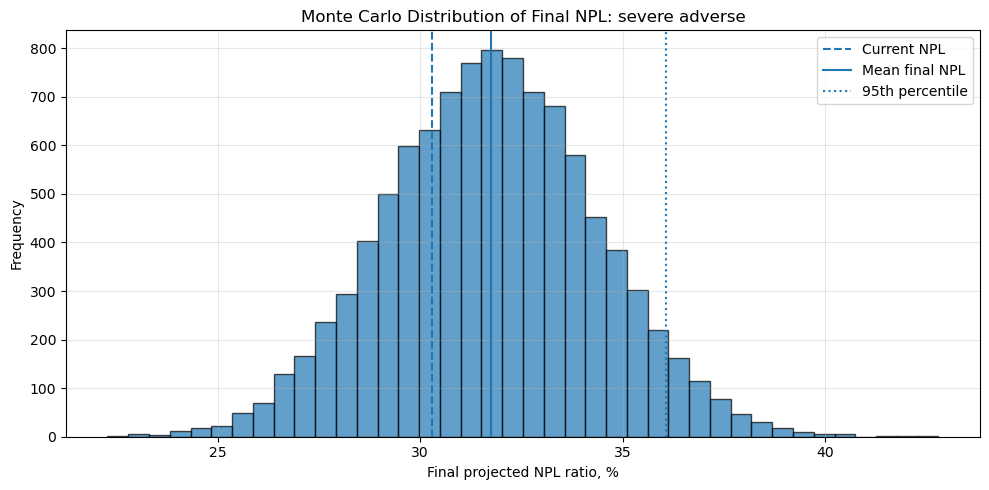

In [11]:
for scenario_name, paths_df in all_simulation_paths.items():
    final_distribution = paths_df[projection_labels[-1]].to_numpy()

    plt.figure(figsize=(10, 5))
    plt.hist(final_distribution, bins=40, edgecolor="black", alpha=0.7)

    plt.axvline(current_npl, linestyle="--", label="Current NPL")
    plt.axvline(np.mean(final_distribution), linestyle="-", label="Mean final NPL")
    plt.axvline(np.percentile(final_distribution, 95), linestyle=":", label="95th percentile")

    plt.title(f"Monte Carlo Distribution of Final NPL: {scenario_name}")
    plt.xlabel("Final projected NPL ratio, %")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Visualise percentile paths

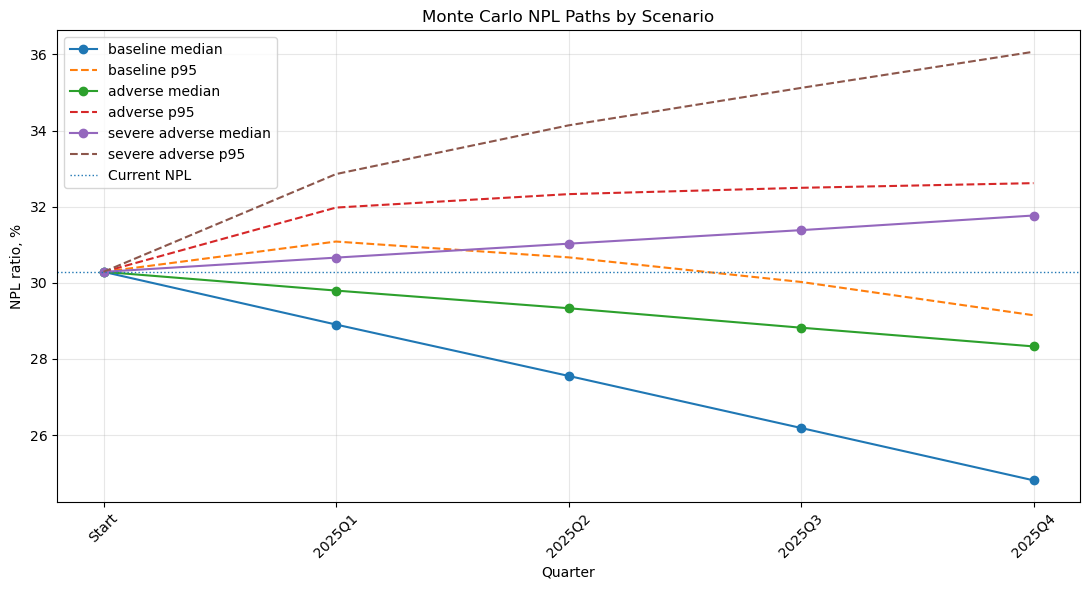

In [12]:
plt.figure(figsize=(11, 6))

for scenario_name, group in percentile_paths.groupby("scenario", sort=False):
    plt.plot(
        group["quarter"],
        group["median"],
        marker="o",
        label=f"{scenario_name} median"
    )
    plt.plot(
        group["quarter"],
        group["p95"],
        linestyle="--",
        label=f"{scenario_name} p95"
    )

plt.axhline(current_npl, linestyle=":", linewidth=1, label="Current NPL")

plt.title("Monte Carlo NPL Paths by Scenario")
plt.xlabel("Quarter")
plt.ylabel("NPL ratio, %")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()